# The Linear Algebra Inside a Football Tracker
**Linear Algebra**

This is a walkthrough of the math behind my project. The project takes ordinary broadcast football footage and turns it into a top-down map of where every player is standing. Almost every working piece of it is linear algebra, so this notebook rebuilds those pieces from scratch on small made-up data, using only `numpy` and `matplotlib`.

The big picture is two engines. One is **geometry**, figuring out *where* things are on the field. The other is **appearance**, figuring out *which team* a player is on. Everything below is one of those two.

Every section follows the same four beats, so I can talk through each one the same way:

1. **The problem** I am trying to solve.
2. **What goes in**, and where it comes from in the live program.
3. **The linear algebra** that does the work.
4. **What comes out**, and how the rest of the program uses it.

Parts 1 to 4 are the geometry engine and Part 5 is the appearance engine. In order they are the homography map, recovering it with the SVD, the width limit from conditioning, the camera-motion chain, and the team-color classifier.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(2026)

## Part 1. The Homography, One Matrix That Warps Field to Screen

**The problem.** Convert a field position in yards to a screen pixel, or a pixel back to a field position. In flat 2D this relationship is not linear, because a camera divides by depth, so a plain stretch can never describe it.

**What goes in.** The homography $H$, plus one or more 2D points. For a player the point is his *foot point*, the bottom center of the box the detector (RT-DETR) draws around him, $u=(x_1+x_2)/2$ and $v=y_2$. I use the feet because that is where the player actually touches the ground.

**The linear algebra.** Add a $1$ to each 2D point so it becomes 3D, multiply by $H$, then divide by the third coordinate to drop back to 2D:

$$
\begin{pmatrix} x' \\ y' \\ w \end{pmatrix} = H \begin{pmatrix} u \\ v \\ 1 \end{pmatrix},
\qquad (X,Y) = \left(\frac{x'}{w},\ \frac{y'}{w}\right).
$$

The trick is that the extra dimension lets one matrix do something that looks curved back in 2D. The final divide by $w$ *is* the perspective, the part that shrinks things with distance. This is `_apply_h` in the real code.

**What comes out.** The mapped 2D points. Every projection in the program, the field grid drawn onto the broadcast and the player feet dropped onto the map, is one call to this single function.

In [2]:
def apply_h(H, pts):
    """Apply a 3x3 homography to Nx2 points, through homogeneous coordinates."""
    pts = np.asarray(pts, float).reshape(-1, 2)
    homog = np.hstack([pts, np.ones((len(pts), 1))])   # the lift: append a 1
    out = (H @ homog.T).T                              # one linear map in 3D
    return out[:, :2] / out[:, 2:3]                    # divide by w, back to 2D

Here is the perspective effect made visible. Six points spaced evenly down the field come out unevenly spaced in pixels. Nothing fancy causes that, it is purely the final divide by $w$.

equal field spacing (yards): [20. 20. 20. 20. 20.]
unequal pixel spacing      : [38. 38. 38. 38. 38.]


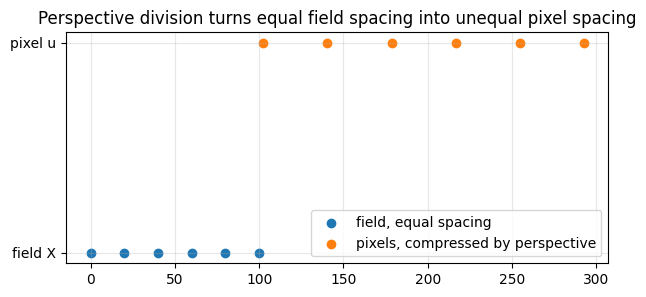

In [3]:
H1 = np.array([[2.0, 0.30, 100.0],
               [0.10, 1.50,  80.0],
               [0.0060, 0.0020, 1.0]])    # perspective grows down the field (the X term)

field_row = np.column_stack([np.linspace(0, 100, 6), np.full(6, 26.6)])
pix_row = apply_h(H1, field_row)

print("equal field spacing (yards):", np.diff(field_row[:, 0]))
print("unequal pixel spacing      :", np.round(np.diff(pix_row[:, 0]), 1))

plt.figure(figsize=(7, 3))
plt.scatter(field_row[:, 0], np.zeros(6), label="field, equal spacing")
plt.scatter(pix_row[:, 0], np.ones(6), label="pixels, compressed by perspective")
plt.yticks([0, 1], ["field X", "pixel u"]); plt.legend(); plt.grid(True, alpha=0.3)
plt.title("Perspective division turns equal field spacing into unequal pixel spacing")
plt.show()

## Part 2. Recovering $H$ with the SVD

**The problem.** $H$ is unknown. Recover the field-to-image calibration from a handful of known matches between field points and the pixels they land on.

**What goes in.** At least four matches. The pixel side comes from running edge detection and a Hough transform to find the painted yard lines and sidelines, then intersecting them. The field side is the known yardage of those same lines, for example a yard line at $X=30$ crossing a sideline at $Y=0$.

**The linear algebra.** Each match gives two linear equations in the nine unknown entries of $H$. Stack them into a tall matrix $A$ and solve

$$
A\,h = 0, \qquad \lVert h \rVert = 1 ,
$$

where $h$ is $H$ unrolled into a vector. The length-1 rule just throws out the useless all-zeros answer. The SVD gives the answer directly, it is the direction $A$ stretches the *least*, which is the last row of $V^{\top}$ (the smallest singular value). With perfect data that direction is the exact null space of $A$. With real noisy data it is the closest thing to it.

**What comes out.** The matrix $H$, plus its inverse for going the other way. This is the calibration every projection in Part 1 relies on.

In [4]:
def dlt(src, dst):
    """Solve for H mapping src points to dst, via the SVD null space.
    Returns (H, singular_values)."""
    A = []
    for (sx, sy), (dx, dy) in zip(src, dst):
        A.append([-sx, -sy, -1,  0,   0,  0, dx*sx, dx*sy, dx])
        A.append([ 0,   0,  0, -sx, -sy, -1, dy*sx, dy*sy, dy])
    A = np.asarray(A, float)
    U, S, Vt = np.linalg.svd(A)
    H = Vt[-1].reshape(3, 3)        # smallest-singular-value right vector
    return H / H[2, 2], S

In [5]:
# Ground-truth H from the four field corners to four pixel corners.
field_corners = np.array([[0,0],[100,0],[100,53.3],[0,53.3]], float)
pix_corners   = np.array([[120,300],[520,300],[610,140],[60,150]], float)
H_true, _ = dlt(field_corners, pix_corners)     # field -> pixel

# Recover H_true from 12 clean correspondences, to show the solve is exact.
fp = np.column_stack([rng.uniform(0,100,12), rng.uniform(0,53,12)])
pp = apply_h(H_true, fp)
H_rec, S = dlt(fp, pp)
print("max entrywise error between recovered and true H:", np.abs(H_rec - H_true).max())

max entrywise error between recovered and true H: 2.3661073100811336e-11


With $H$ recovered, the evenly spaced field grid projects into the converging, perspective view that a broadcast camera actually sees.

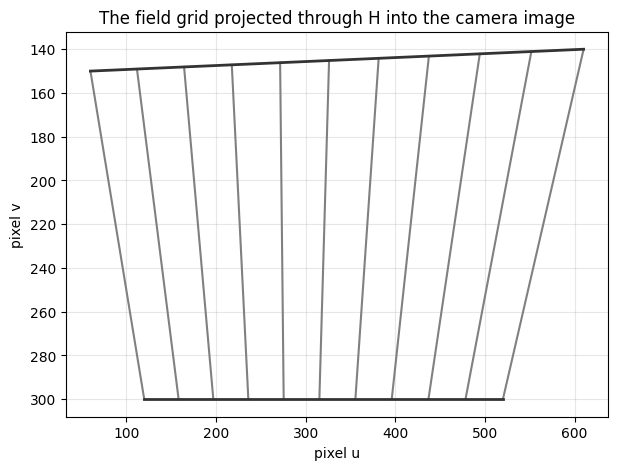

In [6]:
plt.figure(figsize=(7, 5))
for X in range(0, 101, 10):
    seg = apply_h(H_true, [[X, 0], [X, 53.3]])
    plt.plot(seg[:, 0], seg[:, 1], color="0.5")
for Y in (0, 53.3):
    seg = apply_h(H_true, [[0, Y], [100, Y]])
    plt.plot(seg[:, 0], seg[:, 1], color="0.2", lw=2)
plt.gca().invert_yaxis(); plt.title("The field grid projected through H into the camera image")
plt.xlabel("pixel u"); plt.ylabel("pixel v"); plt.grid(True, alpha=0.3)
plt.show()

## Part 3. The Width Limit, When the Calibration Is Only Half Trustworthy

**The problem.** Can I trust the recovered $H$ equally in both directions? Often not, and I need to know which.

**What goes in.** The singular values of the calibration matrix $A$, and the pixel matches, which carry real localization error of roughly 10 to 30 pixels per detected intersection on this footage.

**The linear algebra.** Look at the gap between the two smallest singular values:

$$
\text{cond\_gap} = \frac{\sigma_{n-1}}{\sigma_n}.
$$

$\sigma_n$ is the null direction I solved for in Part 2. If the next one up, $\sigma_{n-1}$, also collapses toward zero, then a whole second direction of $H$ is barely pinned down. In that direction a tiny pixel error gets divided by a tiny number and blows up into a huge field error.

**What comes out.** A per-frame trust call. When the gap is wide the frame gets full 2D placement. When it is narrow the program keeps the down-field number, throws out the width number, and the minimap pins that player to the sideline instead of inventing a sideways position.

In [8]:
def conditioning_experiment(width_band, n=8, noise=1.0, trials=300):
    """Sample n correspondences with field-y in width_band, recover H from
    1-pixel-noisy pixels many times, measure error at a far-sideline test point."""
    f = np.column_stack([rng.uniform(5, 95, n), rng.uniform(*width_band, n)])
    p = apply_h(H_true, f)
    _, S = dlt(f, p)
    cond_gap = S[-2] / S[-1]

    test = np.array([[50.0, 48.0]])
    pt_true = apply_h(H_true, test)
    errs = [np.abs(apply_h(np.linalg.inv(dlt(f, p + rng.normal(0, noise, p.shape))[0]), pt_true) - test)[0]
            for _ in range(trials)]
    return cond_gap, np.mean(errs, axis=0)

cg_wide,   err_wide   = conditioning_experiment((2, 51))
cg_narrow, err_narrow = conditioning_experiment((24, 29))
print(f"wide width   : cond_gap = {cg_wide:12.1f}   width error = {err_wide[1]:.2f} yd")
print(f"narrow width : cond_gap = {cg_narrow:12.1f}   width error = {err_narrow[1]:.2f} yd")

wide width   : cond_gap = 570763938096171.6   width error = 0.16 yd
narrow width : cond_gap = 35475900150480.7   width error = 6.14 yd


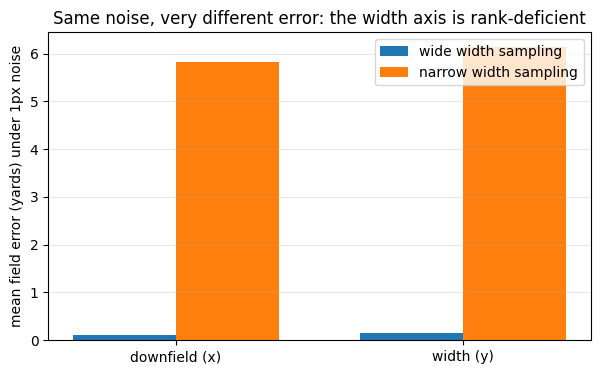

In [9]:
labels = ["downfield (x)", "width (y)"]
xpos = np.arange(2)
plt.figure(figsize=(7, 4))
plt.bar(xpos - 0.18, err_wide,   0.36, label="wide width sampling")
plt.bar(xpos + 0.18, err_narrow, 0.36, label="narrow width sampling")
plt.xticks(xpos, labels); plt.ylabel("mean field error (yards) under 1px noise")
plt.title("Same noise, very different error: the width axis is rank-deficient")
plt.legend(); plt.grid(True, axis="y", alpha=0.3)
plt.show()

## Part 4. The Camera-Motion Chain

**The problem.** Keep a correct map as the view moves, without re-solving from scratch on every frame.

**What goes in.** The anchor homography from Part 2, plus a small per-frame motion matrix $M_i$. I get each $M_i$ by finding ORB feature points in two back-to-back frames, matching them, and running the same solve as Part 2 on the matched pairs (with RANSAC to throw out bad matches).

**The linear algebra.** Multiply the motions together into one product and combine with the anchor:

$$
M = M_n M_{n-1}\cdots M_1, \qquad H_{\text{current}} = H_{\text{anchor}}\, M^{-1}.
$$

Multiplying the matrices chains the moves into one move. The catch is that order matters, matrix multiplication does not commute, so I have to stack the motions in the exact order the frames arrived.

**What comes out.** A fresh pixel-to-field map for every frame, so the field grid stays glued to the field while the camera pans and zooms.

In [7]:
M1 = np.array([[1.0, 0, 8.0],[0, 1.0, 3.0],[0, 0, 1]])    # a pan
M2 = np.array([[1.05, 0, 0],[0, 1.05, 0],[0, 0, 1]])      # a slight zoom

M_pan_then_zoom = M2 @ M1
M_zoom_then_pan = M1 @ M2
print("same matrix?", np.allclose(M_pan_then_zoom, M_zoom_then_pan))

H_pix_to_field = np.linalg.inv(H_true) @ M_pan_then_zoom   # current per-frame map
print("current pixel-to-field map:\n", H_pix_to_field)

same matrix? False
current pixel-to-field map:
 [[  0.2751  -0.1101   1.8709]
 [  0.      -0.5078 143.5526]
 [  0.0001  -0.0026   1.7152]]


The two orderings give different matrices, pan-then-zoom is not the same as zoom-then-pan. That is the concrete reason the chain has to accumulate the motions strictly in frame order.

## Part 5. The Team-Color Classifier

**The problem.** Decide which team a detected player is on, green or white, from the colors inside his box.

**What goes in.** RGB pixels read from the jersey band, the upper part of each player box, so grass and pants do not get a vote. That gives one cloud of colors per team.

**The linear algebra.** Model each team as a flat patch in color space, an average $\mu$ plus the top $k$ principal directions of the centered colors (that is PCA). For a new color the squared distance to a patch is

$$
\text{resid}^2 = \lVert d \rVert^2 - \lVert V_k\, d \rVert^2, \qquad d = x - \mu .
$$

That is Pythagoras. Total squared length, minus the squared length of the part that lies inside the patch, leaves the squared length of the part sticking out. A smaller leftover means the color fits that team better.

**What comes out.** The team label, taken from the smaller leftover, voted across many frames and then locked so a player keeps his color for the rest of the play.

In [10]:
def make_cloud(mu, n):
    return np.array(mu, float) + rng.normal(0, 12, (n, 3))

green = make_cloud([25, 80, 30], 200)      # dark green jerseys, RGB
white = make_cloud([220, 220, 235], 200)   # white jerseys, RGB

def fit_subspace(px, k=1):
    mu = px.mean(axis=0)
    U, S, Vt = np.linalg.svd(px - mu, full_matrices=False)
    return mu, Vt[:k]                        # mean plus top-k principal directions

def residual_sq(px, mu, Vk):
    d = px - mu
    proj = d @ Vk.T
    return (d * d).sum(1) - (proj * proj).sum(1)   # Pythagoras: orthogonal remainder

mu_g, Vg = fit_subspace(green)
mu_w, Vw = fit_subspace(white)

test = np.vstack([make_cloud([25,80,30],100), make_cloud([220,220,235],100)])
truth = np.array([0]*100 + [1]*100)
pred = (residual_sq(test, mu_g, Vg) > residual_sq(test, mu_w, Vw)).astype(int)
print("classification accuracy:", (pred == truth).mean())

classification accuracy: 1.0


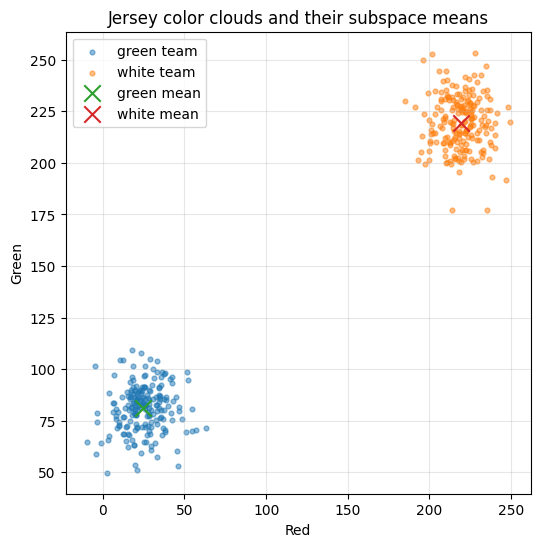

In [11]:
plt.figure(figsize=(6, 6))
plt.scatter(green[:,0], green[:,1], s=12, alpha=0.5, label="green team")
plt.scatter(white[:,0], white[:,1], s=12, alpha=0.5, label="white team")
plt.scatter([mu_g[0]],[mu_g[1]], marker="x", s=140, label="green mean")
plt.scatter([mu_w[0]],[mu_w[1]], marker="x", s=140, label="white mean")
plt.xlabel("Red"); plt.ylabel("Green"); plt.title("Jersey color clouds and their subspace means")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

## Summary

| Section | The problem | The linear algebra | What comes out |
|---|---|---|---|
| 1 | move points field to screen | add a 1, multiply by $H$, divide by $w$ | mapped 2D points |
| 2 | work out the calibration $H$ | SVD null space of $A$ | the $3\times 3$ homography |
| 3 | know which axes to trust | the next singular value of the same $A$ | full 2D, or down-field only |
| 4 | keep $H$ valid as the camera moves | chain the motions by multiplying | per-frame pixel-to-field map |
| 5 | label each player green or white | PCA patches and the leftover distance | the team color, voted and locked |

Two engines, one subject. The geometry engine is a homography, worked out by an SVD, held honest by watching the next singular value of that same solve, and kept current by multiplying the camera motions together. The appearance engine is PCA, which decides the team by how far a color sticks out of each team's patch.